# Credit Card Fraud Detection
**Goal:** Build a classification model to detect fraudulent credit card transactions using transaction amount, time, and anonymised (PCA) features. The dataset is highly imbalanced, so special care is taken in preprocessing, balancing, model choice, and evaluation metrics.

**Dataset:** Kaggle "Credit Card Fraud Detection" — 284,807 transactions, 492 of which are fraud (0.17%).


## Step 1: Import Libraries

In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from collections import Counter

sns.set_style('whitegrid')


## Step 2: Load Dataset & Explore (EDA)
We first load the data and check its shape, missing values, and most importantly, the **class distribution** — since that's the central challenge in this problem.

In [3]:
df = pd.read_csv(r'D:\projects\Cyber Security @Arch_technology\creditcard.csv')
print("Shape:", df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Check for missing values
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 0


In [6]:
# Class distribution - THE key issue
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
print(f"Normal (0): {class_counts[0]} ({class_pct[0]:.4f}%)")
print(f"Fraud  (1): {class_counts[1]} ({class_pct[1]:.4f}%)")


Normal (0): 284315 (99.8273%)
Fraud  (1): 492 (0.1727%)


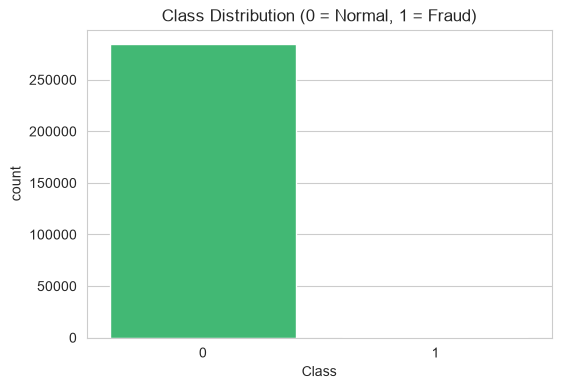

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, hue='Class', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.show()


**Observation:** Only ~0.17% of transactions are fraudulent. This severe imbalance means we cannot rely on plain accuracy as our evaluation metric, and we must handle the imbalance before training.

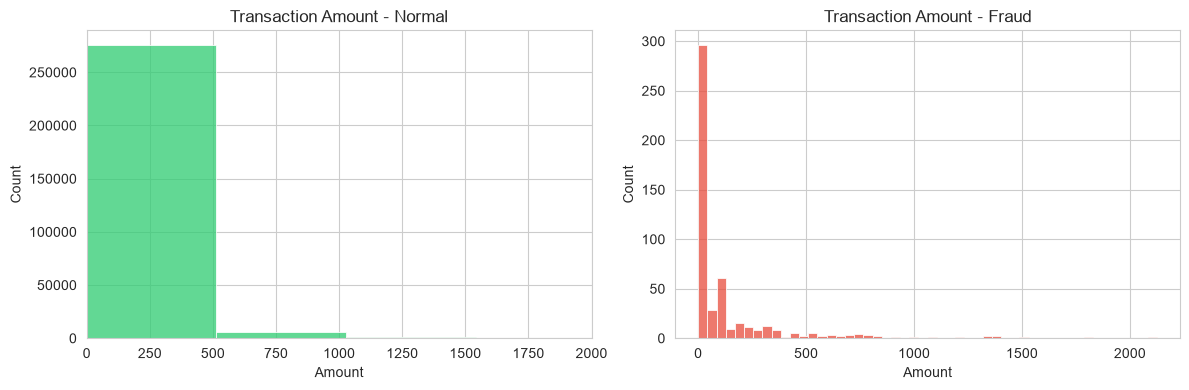

In [8]:
# Amount distribution comparison
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df[df['Class']==0]['Amount'], bins=50, ax=ax[0], color='#2ecc71')
ax[0].set_title('Transaction Amount - Normal')
ax[0].set_xlim(0, 2000)
sns.histplot(df[df['Class']==1]['Amount'], bins=50, ax=ax[1], color='#e74c3c')
ax[1].set_title('Transaction Amount - Fraud')
plt.tight_layout()
plt.show()


## Step 3: Pre-processing
- `V1`-`V28` are already PCA-transformed (so they're already scaled).
- `Amount` and `Time` are NOT scaled in the raw data — we scale them using `StandardScaler`.
- We split into train/test **before** balancing, using stratified sampling so both sets retain the original fraud ratio.

In [9]:
scaler_amount = StandardScaler()
scaler_time = StandardScaler()

df['scaled_amount'] = scaler_amount.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler_time.fit_transform(df['Time'].values.reshape(-1, 1))

df = df.drop(['Amount', 'Time'], axis=1)
df.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows, fraud={y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Test:  {X_test.shape[0]} rows, fraud={y_test.sum()} ({y_test.mean()*100:.4f}%)")


Train: 199364 rows, fraud=344 (0.1725%)
Test:  85443 rows, fraud=148 (0.1732%)


## Step 4: Handle Class Imbalance (SMOTE)
We apply **SMOTE (Synthetic Minority Oversampling Technique)** only on the training set. SMOTE creates synthetic fraud examples by interpolating between existing minority-class samples, rather than just duplicating them. The test set is left untouched so evaluation reflects real-world conditions.

In [11]:
print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE: ", Counter(y_train_res))


Before SMOTE: Counter({0: 199020, 1: 344})
After SMOTE:  Counter({0: 199020, 1: 199020})


## Step 5: Train Classification Models
We train two models for comparison:
1. **Logistic Regression** — simple, interpretable baseline
2. **Random Forest** — handles non-linear relationships, usually performs better on this type of data

In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)
print("Logistic Regression trained.")


Logistic Regression trained.


In [15]:
rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
print("Random Forest trained.")


Random Forest trained.


## Step 6: Evaluation

> **Important:** We avoid relying on plain accuracy. Since 99.8% of transactions are normal, a model that predicts "normal" for everything would score ~99.8% accuracy while catching zero fraud. Instead we use:
> - **Confusion Matrix** — breakdown of correct/incorrect predictions per class
> - **Precision** — of predicted frauds, how many were actually fraud
> - **Recall** — of actual frauds, how many were caught (most critical metric here — missing fraud is costly)
> - **F1-score** — balance between precision and recall
> - **ROC-AUC** and **PR-AUC** — threshold-independent performance measures (PR-AUC is more informative for imbalanced data)

In [16]:
models = {"Logistic Regression": log_reg, "Random Forest": rf}
results = {}

for name, model in models.items():
    print("="*60)
    print(name)
    print("="*60)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print(f"Accuracy: {acc:.4f} (reference only - misleading on imbalanced data)")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"PR-AUC:   {pr_auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=['Normal','Fraud'], digits=4))

    results[name] = {'y_pred': y_pred, 'y_proba': y_proba, 'roc_auc': roc_auc, 'pr_auc': pr_auc}


Logistic Regression
Accuracy: 0.9773 (reference only - misleading on imbalanced data)
ROC-AUC:  0.9660
PR-AUC:   0.7062

              precision    recall  f1-score   support

      Normal     0.9998    0.9775    0.9885     85295
       Fraud     0.0634    0.8784    0.1183       148

    accuracy                         0.9773     85443
   macro avg     0.5316    0.9279    0.5534     85443
weighted avg     0.9982    0.9773    0.9870     85443

Random Forest
Accuracy: 0.9987 (reference only - misleading on imbalanced data)
ROC-AUC:  0.9762
PR-AUC:   0.7734

              precision    recall  f1-score   support

      Normal     0.9997    0.9991    0.9994     85295
       Fraud     0.5970    0.8108    0.6877       148

    accuracy                         0.9987     85443
   macro avg     0.7983    0.9049    0.8435     85443
weighted avg     0.9990    0.9987    0.9988     85443



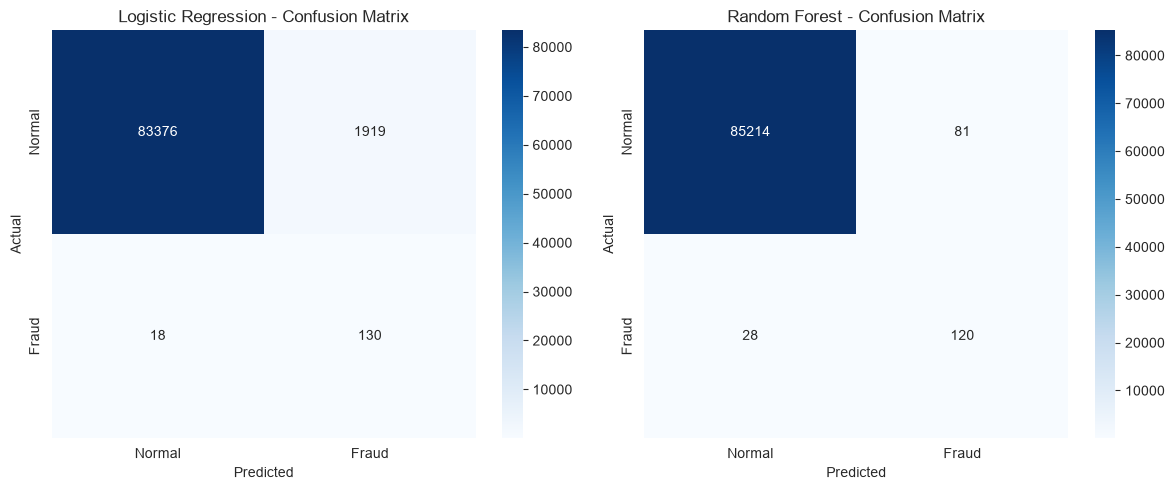

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


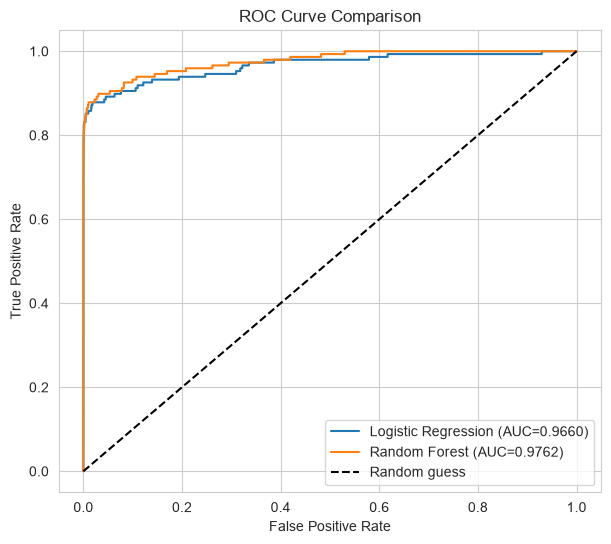

In [18]:
plt.figure(figsize=(7,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.4f})")
plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison'); plt.legend()
plt.show()


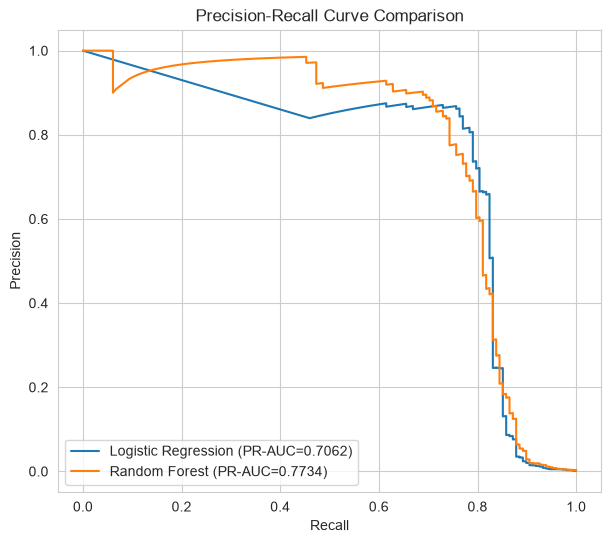

In [19]:
plt.figure(figsize=(7,6))
for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_proba'])
    plt.plot(recall, precision, label=f"{name} (PR-AUC={res['pr_auc']:.4f})")
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison'); plt.legend()
plt.show()


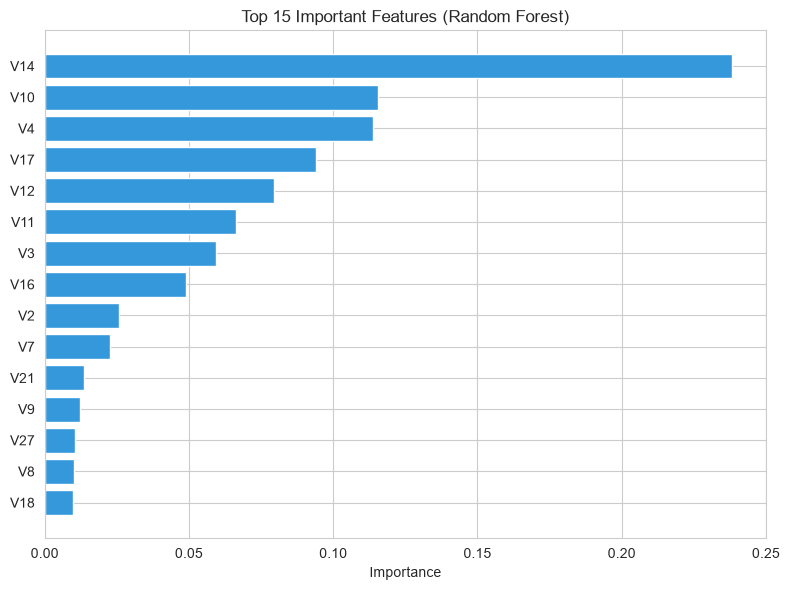

In [20]:
importances = rf.feature_importances_
feat_names = X_test.columns
idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(8,6))
plt.barh(range(len(idx)), importances[idx][::-1], color='#3498db')
plt.yticks(range(len(idx)), [feat_names[i] for i in idx][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Important Features (Random Forest)')
plt.tight_layout()
plt.show()


## Step 7: Conclusion

- The dataset was **extremely imbalanced** (0.17% fraud), so accuracy alone would have been misleading.
- **SMOTE** was used to balance the training data by generating synthetic minority-class samples; the test set was kept untouched to reflect real-world conditions.
- **Random Forest outperformed Logistic Regression** on PR-AUC and overall precision — it caught fraud with far fewer false alarms.
- **Logistic Regression had higher recall but very poor precision** (many false positives) — it flagged far more normal transactions as fraud.
- In fraud detection, **Recall** is usually prioritized over Precision, since missing actual fraud (false negative) is typically more costly than a false alarm. However, too many false positives create operational burden, so the right balance depends on business cost trade-offs — this can be tuned via the classification threshold.
- The most influential features for Random Forest were `V14`, `V12`, `V4`, `V10`, and `V11` — all anonymised PCA components.

**Possible improvements:** try XGBoost/LightGBM, tune the classification threshold based on cost of false positives vs false negatives, try anomaly detection methods (Isolation Forest, Autoencoders), and perform hyperparameter tuning (GridSearchCV) for further gains.
